#IS 470 Lab 11: Improving Model Performance

---
You have been given a data file by the San Francisco Bay Area Rapid Transit (BART), which identifies a set of demographics for residents in a local area. We will use this file to predict whether a resident is Rider or not.<br>
<br>
VARIABLE DESCRIPTIONS:<br>
<br>
Age:  

            1.   14 thru 17
            2.   18 thru 24
            3.   25 thru 34
            4.   35 thru 44
            5.   45 thru 54
            6.   55 thru 64
            7.   65 and Over

DistToWork: Distance to work in miles<br>
DualInc: Is dual income household or not<br>
Education:  
            
            1. Grade 8 or less<br>
            2. Grades 9 to 11<br>
            3. Graduated high school<br>
            4. 1 to 3 years of college<br>
            5. College graduate<br>
            6. Grad Study<br>
Gender:	M or F<br>
Income:
        
            1. Less than $10,000<br>
            2. $10,000 to $14,999<br>
            3. $15,000 to $19,999<br>
            4. $20,000 to $24,999<br>
            5. $25,000 to $29,999<br>
            6. $30,000 to $39,999<br>
            7. $40,000 to $49,999<br>
            8. $50,000 to $74,999<br>
            9. $75,000 or more<br>
Language:	Language spoken at home<br>
NbrInHouseHold:	Number in household<br>
NbrInHouseholdUnder18:	Number in household under 18 years old<br>
OwnRent:	Own, rent, or live with parents<br>
YrsInArea:	Years lived in bay area<br>
Rider:	No, Non-rider; Yes, Rider<br>
<br>
Target variable: **Rider**

###1. Upload and clean data

In [86]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [87]:
# Import libraries
import pandas as pd
from sklearn import preprocessing
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression # Try to use this in the exercise
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [88]:
# Read data
BartRider = pd.read_csv("/content/drive/MyDrive/IS470_data/BartRider.csv")
BartRider

,Age,DistToWork,DualInc,Education,Gender,Income,Language,NbrInHouseHold,NbrInHouseholdUnder18,OwnRent,YrsInArea,Rider
0,3,10,N,4,F,7,English,1,0,Rent,3,Yes
1,3,11,N,4,M,6,English,3,1,Rent,2,No
2,2,10,N,5,M,6,English,2,0,Rent,3,No
3,5,6,Y,5,M,4,English,3,0,Rent,5,No
4,4,9,N,4,F,4,English,3,1,Rent,4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
5488,2,9,N,2,F,1,English,5,1,Parent,6,Yes
5489,2,9,N,2,F,2,Other,4,1,Parent,4,Yes
5490,1,13,N,2,F,2,Spanish,4,2,Parent,1,Yes
5491,4,9,N,3,M,1,English,3,2,Parent,4,Yes


In [89]:
# Show the head rows of a data frame
BartRider.head()

,Age,DistToWork,DualInc,Education,Gender,Income,Language,NbrInHouseHold,NbrInHouseholdUnder18,OwnRent,YrsInArea,Rider
0,3,10,N,4,F,7,English,1,0,Rent,3,Yes
1,3,11,N,4,M,6,English,3,1,Rent,2,No
2,2,10,N,5,M,6,English,2,0,Rent,3,No
3,5,6,Y,5,M,4,English,3,0,Rent,5,No
4,4,9,N,4,F,4,English,3,1,Rent,4,No


In [90]:
# Examine variable type
BartRider.dtypes

,0
Age,int64
DistToWork,int64
DualInc,object
Education,int64
Gender,object
Income,int64
Language,object
NbrInHouseHold,int64
NbrInHouseholdUnder18,int64
OwnRent,object


In [91]:
# Change categorical variables to "category"
BartRider['DualInc'] = BartRider['DualInc'].astype('category')
BartRider['Gender'] = BartRider['Gender'].astype('category')
BartRider['Language'] = BartRider['Language'].astype('category')
BartRider['OwnRent'] = BartRider['OwnRent'].astype('category')
BartRider['Rider'] = BartRider['Rider'].astype('category')

In [92]:
# Examine variable type
BartRider.dtypes

,0
Age,int64
DistToWork,int64
DualInc,category
Education,int64
Gender,category
Income,int64
Language,category
NbrInHouseHold,int64
NbrInHouseholdUnder18,int64
OwnRent,category


###2. Prepare data set for classification

In [93]:
# Create dummy variables
BartRider = pd.get_dummies(BartRider, columns=['DualInc','Gender','Language','OwnRent'], drop_first=True)
BartRider

,Age,DistToWork,Education,Income,NbrInHouseHold,NbrInHouseholdUnder18,YrsInArea,Rider,DualInc_Y,Gender_M,Language_Other,Language_Spanish,OwnRent_Parent,OwnRent_Rent
0,3,10,4,7,1,0,3,Yes,False,False,False,False,False,True
1,3,11,4,6,3,1,2,No,False,True,False,False,False,True
2,2,10,5,6,2,0,3,No,False,True,False,False,False,True
3,5,6,5,4,3,0,5,No,True,True,False,False,False,True
4,4,9,4,4,3,1,4,No,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5488,2,9,2,1,5,1,6,Yes,False,False,False,False,True,False
5489,2,9,2,2,4,1,4,Yes,False,False,True,False,True,False
5490,1,13,2,2,4,2,1,Yes,False,False,False,True,True,False
5491,4,9,3,1,3,2,4,Yes,False,True,False,False,True,False


In [94]:
# Partition the data
target = BartRider['Rider']
predictors = BartRider.drop(['Rider'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(3845, 13) (1648, 13) (3845,) (1648,)


In [95]:
# Examine the porportion of target variable for training data set
print(target_train.value_counts(normalize=True))

Rider
No     0.572952
Yes    0.427048
Name: proportion, dtype: float64


In [96]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

Rider
No     0.57949
Yes    0.42051
Name: proportion, dtype: float64


## 3. Decision Tree model prediction

In [97]:
# Build a decision tree model on training data with max_depth = 3
model = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3)
model.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)

[Text(0.5769230769230769, 0.875, 'OwnRent_Parent <= 0.5\nentropy = 0.985\nsamples = 3845\nvalue = [2203, 1642]\nclass = No'),
 Text(0.3076923076923077, 0.625, 'OwnRent_Rent <= 0.5\nentropy = 0.836\nsamples = 2846\nvalue = [2088, 758]\nclass = No'),
 Text(0.4423076923076923, 0.75, 'True  '),
 Text(0.15384615384615385, 0.375, 'YrsInArea <= 5.5\nentropy = 0.619\nsamples = 1576\nvalue = [1334.0, 242.0]\nclass = No'),
 Text(0.07692307692307693, 0.125, 'entropy = 0.655\nsamples = 1101\nvalue = [915.0, 186.0]\nclass = No'),
 Text(0.23076923076923078, 0.125, 'entropy = 0.523\nsamples = 475\nvalue = [419, 56]\nclass = No'),
 Text(0.46153846153846156, 0.375, 'NbrInHouseHold <= 3.5\nentropy = 0.975\nsamples = 1270\nvalue = [754, 516]\nclass = No'),
 Text(0.38461538461538464, 0.125, 'entropy = 0.966\nsamples = 1196\nvalue = [727, 469]\nclass = No'),
 Text(0.5384615384615384, 0.125, 'entropy = 0.947\nsamples = 74\nvalue = [27, 47]\nclass = Yes'),
 Text(0.8461538461538461, 0.625, 'Education <= 4.5\n

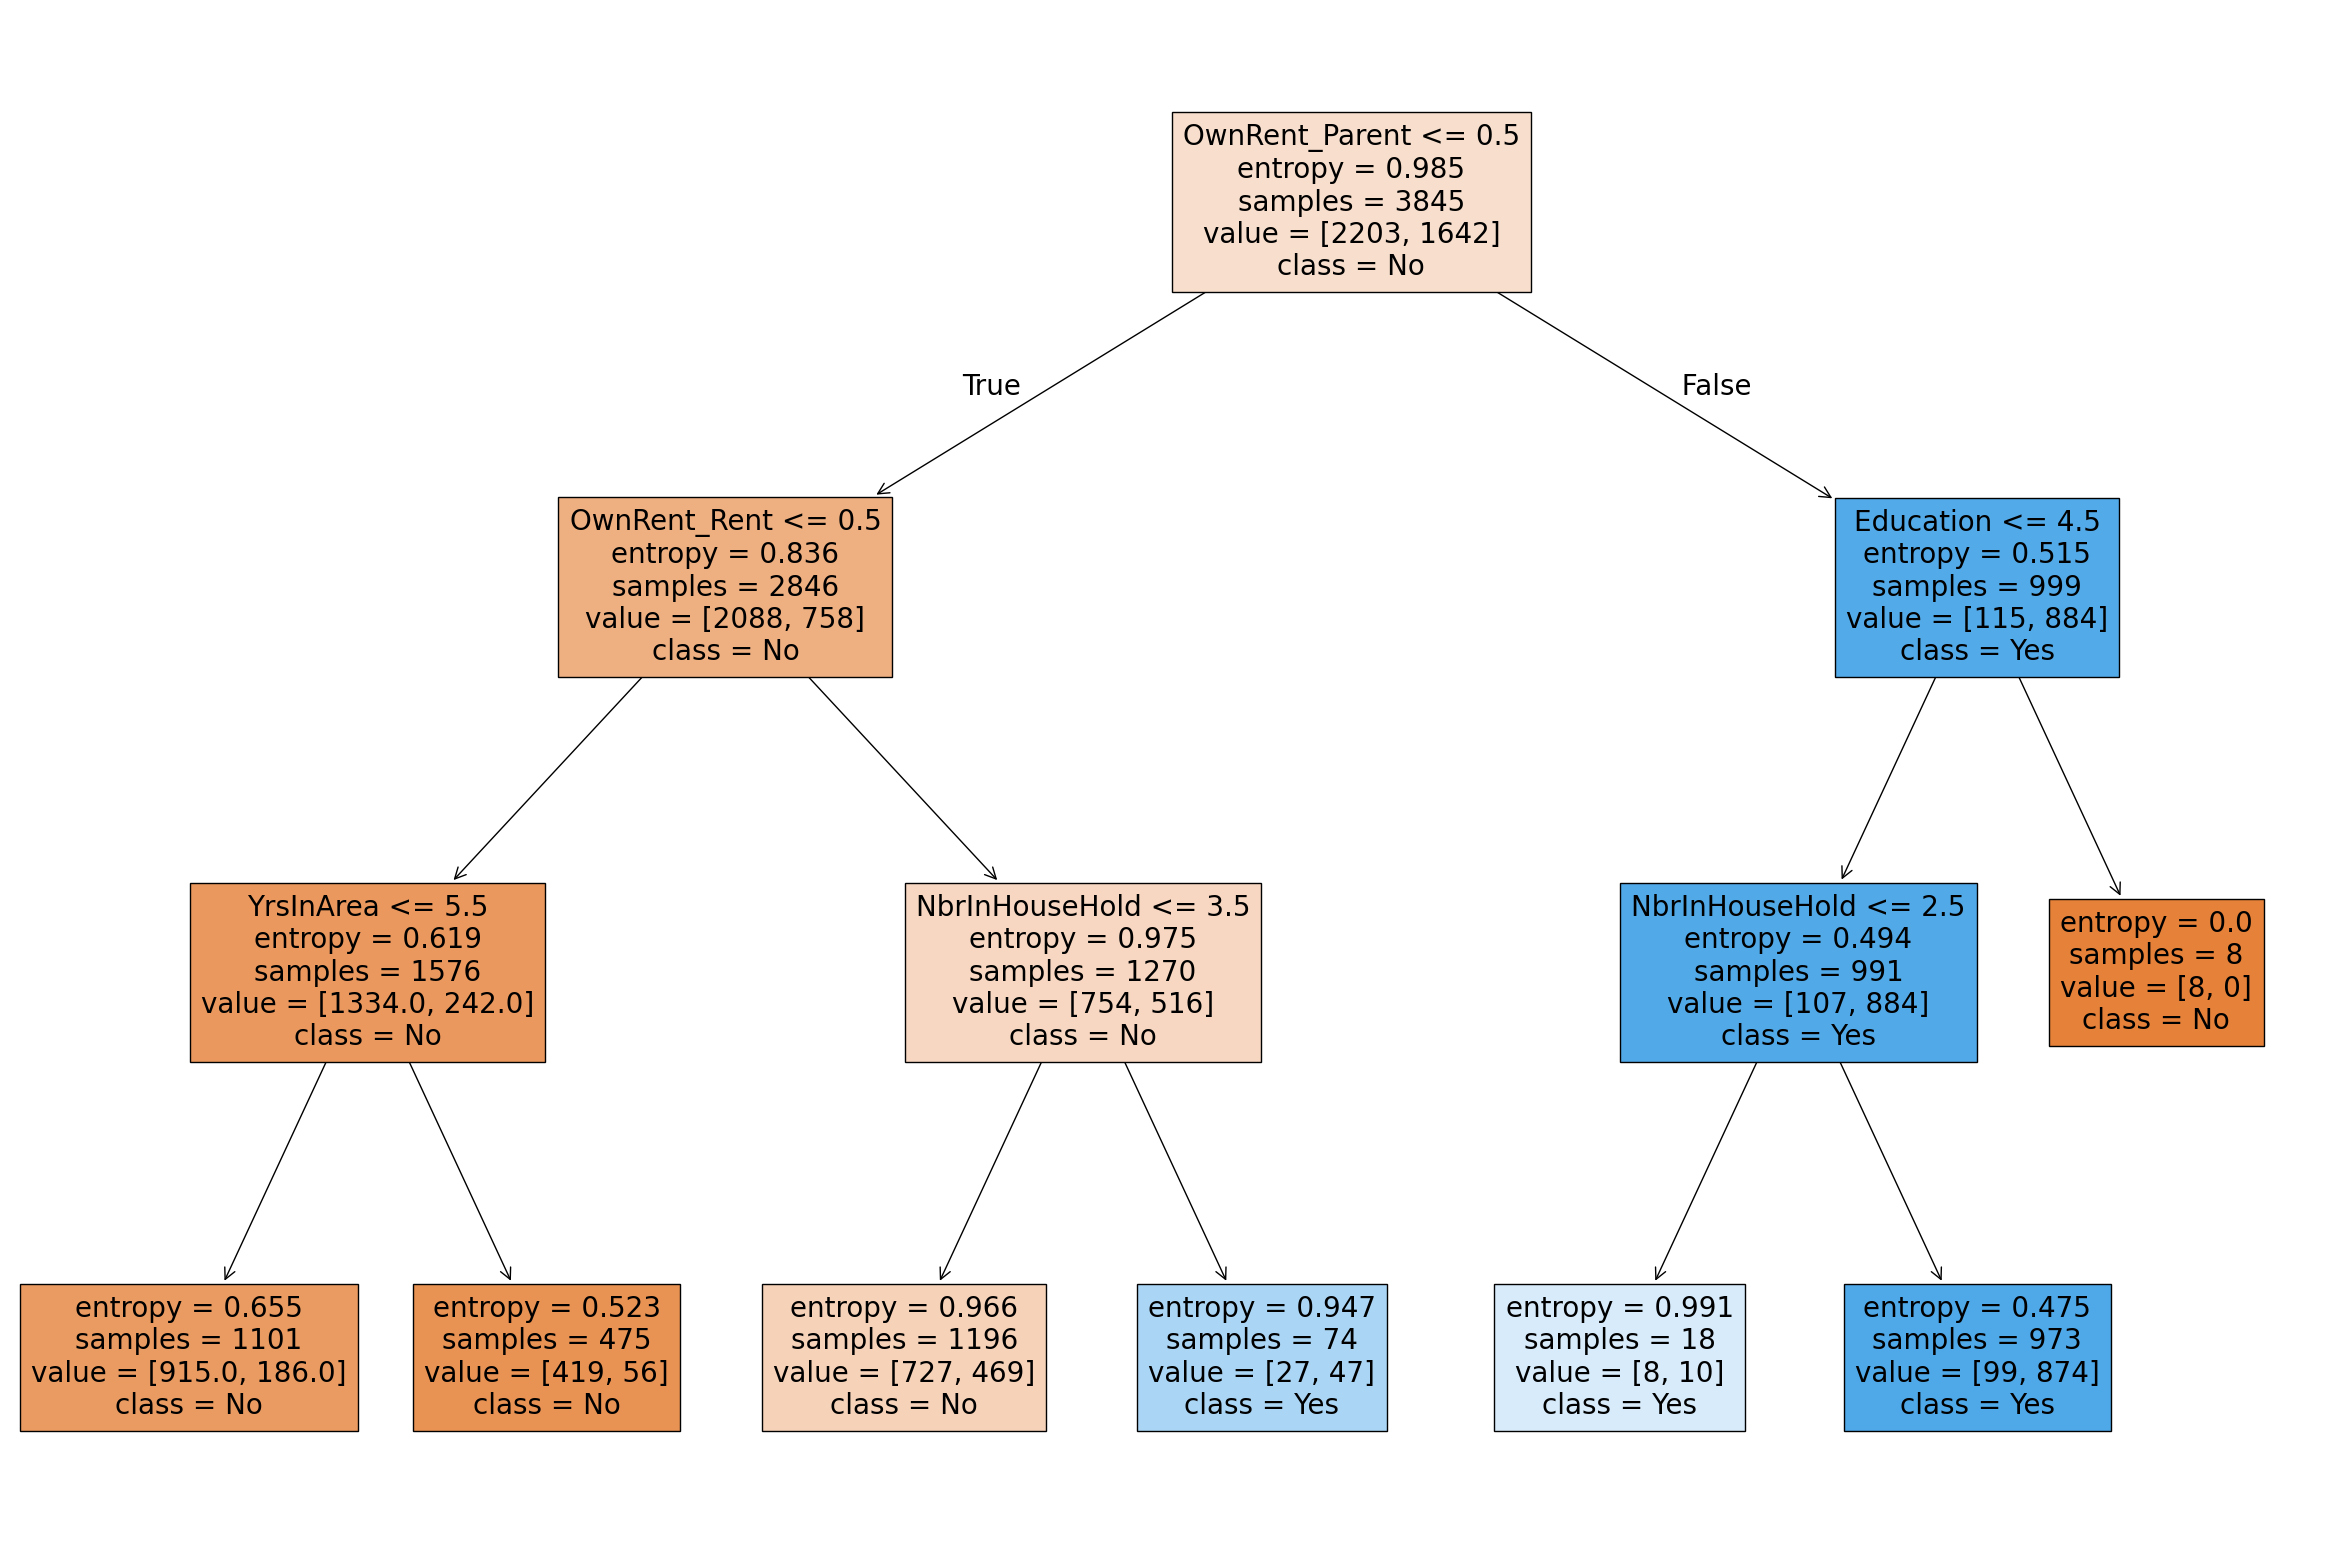

In [98]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model,
               feature_names=list(predictors_train.columns),
               class_names=['No','Yes'],
               filled=True)

In [99]:
# Make predictions on testing data
prediction_on_test = model.predict(predictors_test)

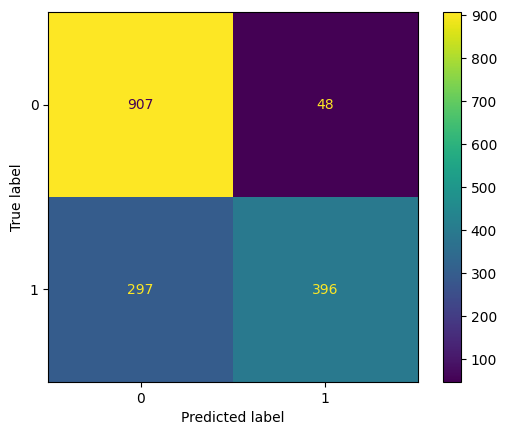

In [100]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [101]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.75      0.95      0.84       955
         Yes       0.89      0.57      0.70       693

    accuracy                           0.79      1648
   macro avg       0.82      0.76      0.77      1648
weighted avg       0.81      0.79      0.78      1648



## 4. Voting ensemble prediction

In [102]:
# Create three learners
estimators = []
learner_1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3)
estimators.append(("Decision_Tree", learner_1))
learner_2 = SVC(C=1)
estimators.append(("SVM1", learner_2))
learner_3 = SVC(C=5)
estimators.append(("SVM2", learner_3))

In [103]:
# Create a voting model
model_voting = VotingClassifier(estimators)
model_voting.fit(predictors_train, target_train)

VotingClassifier(estimators=[('Decision_Tree',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=3,
                                                     random_state=1)),
                             ('SVM1', SVC(C=1)), ('SVM2', SVC(C=5))])

In [104]:
# Make predictions on testing data
prediction_on_test = model_voting.predict(predictors_test)

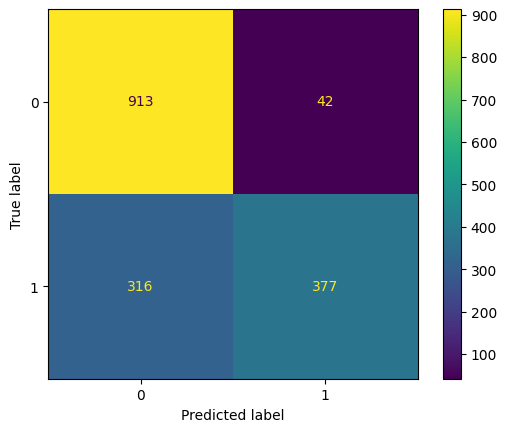

In [105]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [106]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.74      0.96      0.84       955
         Yes       0.90      0.54      0.68       693

    accuracy                           0.78      1648
   macro avg       0.82      0.75      0.76      1648
weighted avg       0.81      0.78      0.77      1648



## 5. Bagging ensemble prediction

In [107]:
model_bagging = BaggingClassifier(estimator=DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3), n_estimators=20, random_state=1)
model_bagging.fit(predictors_train, target_train)

BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                   max_depth=3,
                                                   random_state=1),
                  n_estimators=20, random_state=1)

In [108]:
# Make predictions on testing data
prediction_on_test = model_bagging.predict(predictors_test)

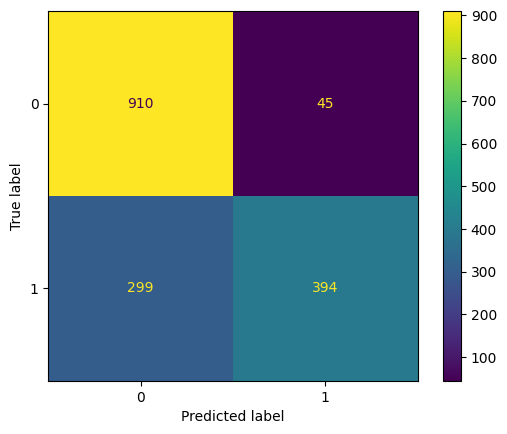

In [109]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [110]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.75      0.95      0.84       955
         Yes       0.90      0.57      0.70       693

    accuracy                           0.79      1648
   macro avg       0.83      0.76      0.77      1648
weighted avg       0.81      0.79      0.78      1648



## 6. Boosting ensemble prediction

In [111]:
# Bagging based on decision tree model
model_Boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3), n_estimators=10, random_state=1)
model_Boost.fit(predictors_train, target_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=3,
                                                    random_state=1),
                   n_estimators=10, random_state=1)

In [112]:
# Make predictions on testing data
prediction_on_test = model_Boost.predict(predictors_test)

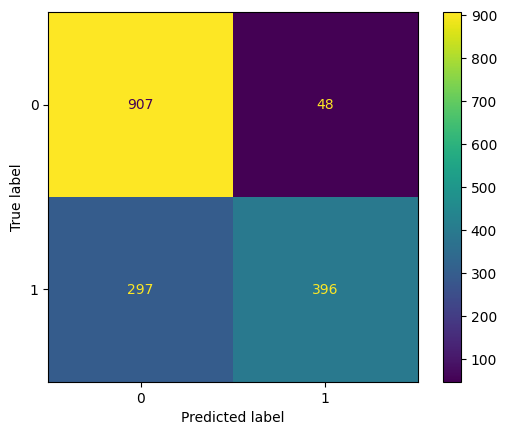

In [113]:
# Examine the evaluation results on testing data: confusion_matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [114]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.75      0.95      0.84       955
         Yes       0.89      0.57      0.70       693

    accuracy                           0.79      1648
   macro avg       0.82      0.76      0.77      1648
weighted avg       0.81      0.79      0.78      1648



**Exercise**. Make your own ensemble that uses at least four classifiers (estimators). Your ensemble model can be voting, bagging, or boosting.

In [115]:
# Import MLP Classifier
from sklearn.neural_network import MLPClassifier

# Create four learners
estimators = []
learner_1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 4)
estimators.append(("Decision_Tree", learner_1))
learner_2 = SVC(C=2)
estimators.append(("SVM1", learner_2))
learner_3 = SVC(C=4)
estimators.append(("SVM2", learner_3))
learner_4 = MLPClassifier(hidden_layer_sizes=(16,8), max_iter=10000, random_state=1)
estimators.append(("MLP", learner_4))

In [116]:
# Create a voting model
model_voting = VotingClassifier(estimators)
model_voting.fit(predictors_train, target_train)

VotingClassifier(estimators=[('Decision_Tree',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=4,
                                                     random_state=1)),
                             ('SVM1', SVC(C=2)), ('SVM2', SVC(C=4)),
                             ('MLP',
                              MLPClassifier(hidden_layer_sizes=(16, 8),
                                            max_iter=10000, random_state=1))])

In [117]:
# Make predictions on testing data
prediction_on_test = model_voting.predict(predictors_test)

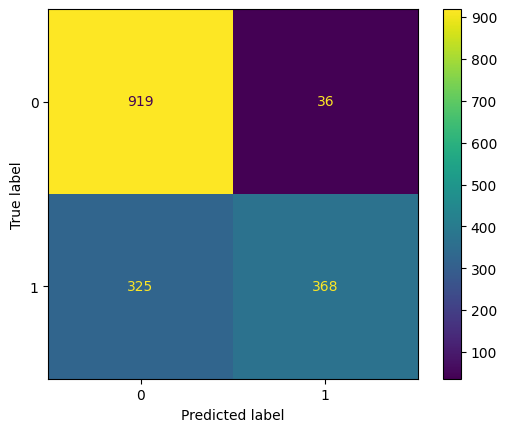

In [118]:
# Examine the evaluation results on testing data: confusion matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [119]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.74      0.96      0.84       955
         Yes       0.91      0.53      0.67       693

    accuracy                           0.78      1648
   macro avg       0.82      0.75      0.75      1648
weighted avg       0.81      0.78      0.77      1648



**Extra credit (3 points)**. Try different ensembles to see if you can improve the model's performance.  If you reach an overall accuracy of 80% or higher, you'll earn extra points. The person with the highest overall accuracy in the class will receive an additional point.

In [120]:
from sklearn.model_selection import GridSearchCV

In [121]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10]
}

param_grid_svm1 = {
    'C': [0.5, 1, 2],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_svm2 = {
    'C': [4, 6, 8],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

param_grid_mlp = {
    'hidden_layer_sizes': [(8, 4), (16, 8), (32, 16)],
    'activation': ['relu', 'tanh', 'logistic'],
    'max_iter': [1000]
}

In [122]:
# Figure out the best decision tree
search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid_dt,
    cv=5,
    n_jobs=-1
)
search_dt.fit(predictors_train, target_train)
best_dt = search_dt.best_estimator_
print(best_dt)

DecisionTreeClassifier(max_depth=4, random_state=1)


In [123]:
# figure out the best SVM 1
search_svm1 = GridSearchCV(
    SVC(),
    param_grid_svm1,
    cv=3,
    n_jobs=-1
)
search_svm1.fit(predictors_train, target_train)
best_svm1 = search_svm1.best_estimator_
print(best_svm1)

SVC(C=0.5)


In [124]:
# figure out the best SVM 2
search_svm2 = GridSearchCV(
    SVC(),
    param_grid_svm2,
    cv=3,
    n_jobs=-1
)
search_svm2.fit(predictors_train, target_train)
best_svm2 = search_svm2.best_estimator_
print(best_svm2)

SVC(C=4, gamma='auto')


In [85]:
# figure out the best MLP
search_mlp = GridSearchCV(
    MLPClassifier(random_state=1),
    param_grid_mlp,
    cv=5,
    n_jobs=-1
)
search_mlp.fit(predictors_train, target_train)
best_mlp = search_mlp.best_estimator_
print(best_mlp)

MLPClassifier(activation='logistic', hidden_layer_sizes=(8, 4), max_iter=1000,
              random_state=1)


In [126]:
# build the ensemble with the best estimators
estimators = [
    ('Decision Tree', best_dt),
    ('SVM1', best_svm1),
    ('SVM2', best_svm2),
    ('MLP', best_mlp)
]
ensemble = VotingClassifier(estimators, voting='hard')
model_voting.fit(predictors_train, target_train)

VotingClassifier(estimators=[('Decision_Tree',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=4,
                                                     random_state=1)),
                             ('SVM1', SVC(C=2)), ('SVM2', SVC(C=4)),
                             ('MLP',
                              MLPClassifier(hidden_layer_sizes=(16, 8),
                                            max_iter=10000, random_state=1))])

In [127]:
# evaluate
prediction_on_test = model_voting.predict(predictors_test)

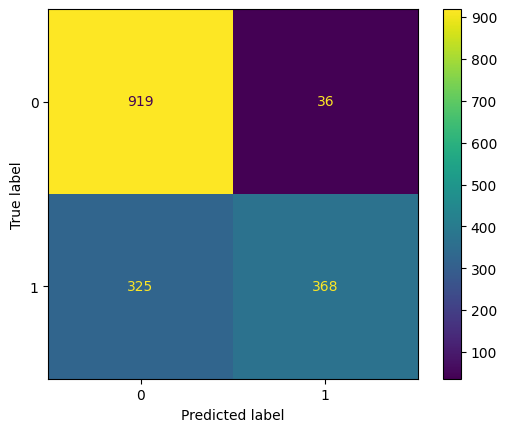

In [128]:
# confusion matrix
cm = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(cm).plot()

In [129]:
# classification report
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

          No       0.74      0.96      0.84       955
         Yes       0.91      0.53      0.67       693

    accuracy                           0.78      1648
   macro avg       0.82      0.75      0.75      1648
weighted avg       0.81      0.78      0.77      1648



In [130]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/IS470_lab11.ipynb" --to html --output "/content/drive/MyDrive/Output/IS470_Lab11.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470_lab11.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1053252 bytes to /content/drive/MyDrive/Output/IS470_Lab11.html
